# PandaX-4T NR yield model vs PRD Fig. 17 (Monte Carlo)

Drives the diamx `NRYieldPandaX4T` appletree component (`diamx/appletree/components/nr_pandax4t.py`) to produce the NR-column quantities of Fig. 17 of the PandaX-4T signal-response paper (Phys. Rev. D **110**, 023029) **by Monte Carlo** -- a uniform energy spectrum is fed through the P4-NEST plugin chain and the per-event `num_photon` / `num_electron` / `recomb_std` are histogrammed in energy:

- mean light yield  $N_{ph}/\xi$ [photon/keV]
- mean charge yield $N_e/\xi$ [e/keV]
- recombination fluctuation $\Delta r$ (= `recomb_std`)

Sampling (PRD Eq. 1/2, params from Appendix A2): $N_q=B(\xi/W,L)$, $N_i=B(N_q,1/(1+\alpha))$, $r\sim G(\langle r\rangle,\Delta r)$, $N_e=B(N_i,1-r)$, $N_{ph}=N_q-N_e$, with the Eq. 17 P4-NEST recombination correction. Four curves are shown per panel (NEST and P4-NEST, Run0 and Run1); the runs differ by drift field (Run0 ~93 V/cm, Run1 ~84 V/cm) and by the Run1 recombination shift $d_{nr}=-0.043$. Digitized Fig. 17 light-yield curves are overlaid for direct comparison.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import diamx  # registers the p4_nest plugins and the NR component
import appletree as apt
from diamx.appletree.components.nr_pandax4t import NRYieldPandaX4T
from diamx.appletree.get_file_path import get_file_path_diamx

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


## Build the MC component
Register a uniform energy spectrum (1-90 keV) + the P4-NEST NR plugins, then `deduce` the data names we want out (`force_no_eff=True` -- no efficiency stage), and `compile`. `xi_norm_nr=150` keV (see the plugin docstring: Eq. 17 lists 30 keV for NR, but that overshoots; 150 keV -- its ER value -- matches Fig. 17).

In [2]:
comp = NRYieldPandaX4T('nr')
comp.set_config({'lower_energy': 1.0, 'upper_energy': 90.0, 'xi_norm_nr': 150.0})
comp.deduce(
    data_names=['energy', 'num_photon', 'num_electron', 'recomb_std'],
    force_no_eff=True,
)
comp.compile()
print('worksheet        :', [w[0] for w in comp.worksheet])
print('needed_parameters:', sorted(comp.needed_parameters))

worksheet        : ['UniformEnergySpectra', 'NRYieldParamsP4NEST', 'NRTotalQuantaP4NEST', 'NRRecombParamsP4NEST', 'NRIonizationP4NEST', 'NRPhotonElectronP4NEST']
needed_parameters: ['a_nr', 'd_nr', 'field', 'liquid_xe_density', 'p0_nr', 'p1_nr', 'p2_nr', 'p3_nr', 'w']


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


## Nominal parameters and the MC yield function
`mc_yields` simulates `n` events from the component, then bins the per-event `num_photon/energy`, `num_electron/energy` and `recomb_std` in energy to get the mean light yield, charge yield and $\Delta r$ vs NR energy.

In [3]:
pm = apt.Parameter(get_file_path_diamx('pandax4t_nr_par.json'))
pm.sample_prior()
base = pm.get_all_parameter()

def mc_yields(params, n=2_000_000, nbins=45):
    key = apt.get_key()
    key, out = comp.simulate(key, n, params)
    energy, nph, ne, recomb_std = (np.asarray(x) for x in out)
    edges = np.linspace(1, 90, nbins + 1)
    ctr = 0.5 * (edges[:-1] + edges[1:])
    ly = np.full(nbins, np.nan); qy = np.full(nbins, np.nan); dr = np.full(nbins, np.nan)
    idx = np.digitize(energy, edges) - 1
    for b in range(nbins):
        m = idx == b
        if m.sum() > 50:
            ly[b] = np.mean(nph[m] / energy[m])
            qy[b] = np.mean(ne[m] / energy[m])
            dr[b] = np.mean(recomb_std[m])
    return ctr, ly, qy, dr

## Run the four cases
- **NEST Run0/Run1**: Legendre = 0, $A^{NR}=1$, $d_{nr}=0$, field 93 / 84 V/cm.
- **P4-NEST Run0**: Table II coefficients, $d_{nr}=0$, field 93 V/cm.
- **P4-NEST Run1**: Table II coefficients, $d_{nr}=-0.043$, field 84 V/cm.

In [4]:
FIELD_RUN0, FIELD_RUN1 = 93.0, 84.0   # drift field [V/cm]
off = dict(p0_nr=0.0, p1_nr=0.0, p2_nr=0.0, p3_nr=0.0, a_nr=1.0, d_nr=0.0)
cases = {
    'NEST Run0':    dict(base, field=FIELD_RUN0, **off),
    'NEST Run1':    dict(base, field=FIELD_RUN1, **off),
    'P4-NEST Run0': dict(base, field=FIELD_RUN0, d_nr=0.0),
    'P4-NEST Run1': dict(base, field=FIELD_RUN1, d_nr=-0.043),
}
res = {name: mc_yields(p) for name, p in cases.items()}

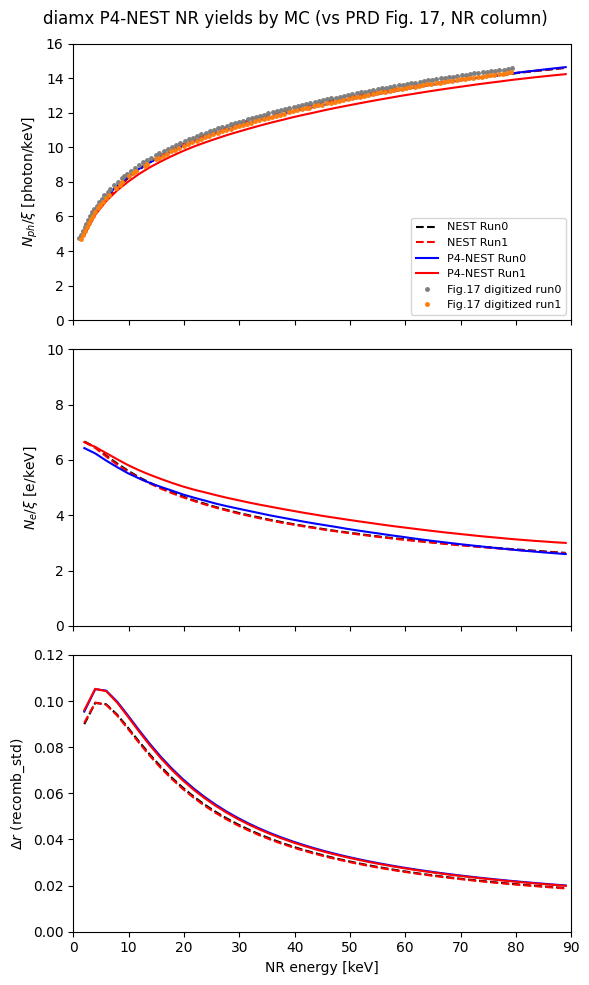

In [5]:
# digitized Fig. 17 light-yield curves (energy [keV], N_ph/xi [photon/keV])
ddir = os.path.join(os.path.dirname(diamx.__file__), 'data')
dig = {}
for run in ['run0', 'run1']:
    f = os.path.join(ddir, f'pandax4t_{run}_nr_ly.csv')
    if os.path.exists(f):
        dig[run] = np.loadtxt(f, delimiter=',')

style = {'NEST Run0': 'k--', 'NEST Run1': 'r--', 'P4-NEST Run0': 'b-', 'P4-NEST Run1': 'r-'}
fig, ax = plt.subplots(3, 1, figsize=(6, 10), sharex=True)
for name, (ctr, ly, qy, dr) in res.items():
    ax[0].plot(ctr, ly, style[name], label=name)
    ax[1].plot(ctr, qy, style[name])
    ax[2].plot(ctr, dr, style[name])
for run, c in [('run0', 'tab:gray'), ('run1', 'tab:orange')]:
    if run in dig:
        ax[0].plot(dig[run][:, 0], dig[run][:, 1], 'o', ms=2.5, color=c,
                   label=f'Fig.17 digitized {run}')
ax[0].set_ylabel(r'$N_{ph}/\xi$ [photon/keV]'); ax[0].set_ylim(0, 16); ax[0].legend(fontsize=8)
ax[1].set_ylabel(r'$N_e/\xi$ [e/keV]'); ax[1].set_ylim(0, 10)
ax[2].set_ylabel(r'$\Delta r$ (recomb_std)'); ax[2].set_ylim(0, 0.12)
ax[2].set_xlabel('NR energy [keV]'); ax[2].set_xlim(0, 90)
fig.suptitle('diamx P4-NEST NR yields by MC (vs PRD Fig. 17, NR column)')
fig.tight_layout(); plt.show()

## Notes
- **MC, not analytic:** every curve is the binned mean of events simulated by the appletree component (uniform spectrum -> P4-NEST plugins), so this exercises the exact chain used for template generation.
- **Two NEST baselines** differ only by drift field; the NR yield is weakly field-dependent ($\sim$field$^{0.05}$), so they nearly overlap, as in Fig. 17.
- **$\Delta r$** uses the quenched electron fraction $\zeta=\langle N_e\rangle/(\langle N_e\rangle+\langle N_{ph}\rangle)$, which reproduces the Fig. 17 scale (~0.1). The literal Eq. A2 form $\langle N_e\rangle W/(1000\xi)$ gives ~0.01 (~10x too small) and appears to be a misprint.
- **$\xi_{norm}^{NR}=150$ keV** (not the 30 keV Eq. 17 lists): with 30 keV the Legendre term overshoots above ~30 keV; 150 keV keeps the correction small over the whole NR range, matching Fig. 17. The two $\xi_{norm}$ values appear swapped in Eq. 17.